# PROYEK DATA SCIENCE

FASHION PRODUCT IMAGES

## Read Data

In [12]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import cv2

# path
CSV_PATH = 'styles.csv'
IMAGES_DIR = 'images'

df = pd.read_csv(CSV_PATH, on_bad_lines='skip')

# Buat kolom baru untuk path gambar
df['image_path'] = df['id'].apply(lambda x: os.path.join(IMAGES_DIR, f"{x}.jpg"))

In [13]:
df['image_exists'] = df['image_path'].apply(lambda x: os.path.exists(x))
df_clean = df[df['image_exists'] == True].reset_index(drop=True)

print(f"Total data yang siap pakai: {len(df_clean)} produk")
display(df_clean.head())

Total data yang siap pakai: 44419 produk


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image_path,image_exists
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,images\15970.jpg,True
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,images\39386.jpg,True
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,images\59263.jpg,True
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,images\21379.jpg,True
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,images\53759.jpg,True


## EDA & FILTERING

In [14]:
# 10 kategori dengan jumlah produk terbanyak
top_10_categories = df_clean['articleType'].value_counts().head(10).index.tolist()
print("10 Kategori Teratas yang akan diproses:", top_10_categories)

# Filter dataset
df_top10 = df_clean[df_clean['articleType'].isin(top_10_categories)]

# Dibatasi maksimal 500 gambar per kategori biar tidak terlalu berat saat training
df_filtered = df_top10.groupby('articleType').head(500).reset_index(drop=True)

10 Kategori Teratas yang akan diproses: ['Tshirts', 'Shirts', 'Casual Shoes', 'Watches', 'Sports Shoes', 'Kurtas', 'Tops', 'Handbags', 'Heels', 'Sunglasses']


In [15]:
print(f"\nTotal dataset setelah difilter: {len(df_filtered)} produk")
print("\nDistribusi Data Saat Ini:")
print(df_filtered['articleType'].value_counts())


Total dataset setelah difilter: 5000 produk

Distribusi Data Saat Ini:
articleType
Shirts          500
Watches         500
Tshirts         500
Casual Shoes    500
Handbags        500
Tops            500
Kurtas          500
Sports Shoes    500
Heels           500
Sunglasses      500
Name: count, dtype: int64


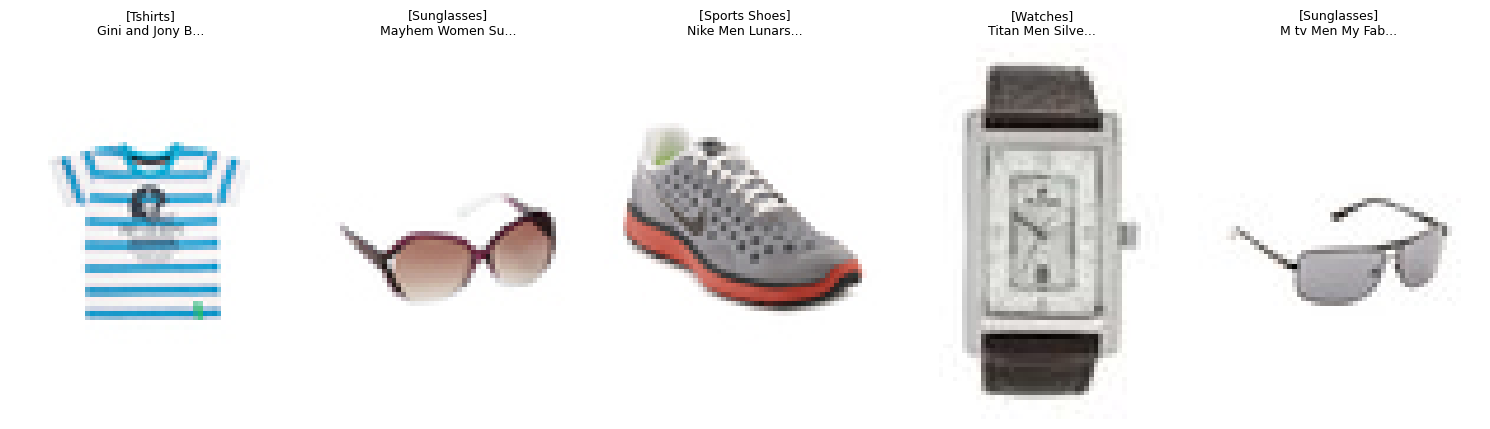

In [16]:
# Visualisasi Sampel Data Acak dari Data yang Sudah Difilter
sample_df = df_filtered.sample(5).reset_index(drop=True)

plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    
    img_path = sample_df['image_path'].iloc[i]
    img = cv2.imread(img_path)
    
    # Konversi BGR ke RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
    
    plt.imshow(img_rgb)
    
    # Memberikan judul kategori dan nama produk
    category = str(sample_df['articleType'].iloc[i])
    product_name = str(sample_df['productDisplayName'].iloc[i])
    plt.title(f"[{category}]\n{product_name[:15]}...", fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Feature Extraction

In [18]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np

print(f"TensorFlow Version: {tf.__version__}")
print("Memuat arsitektur ResNet50...")

# 1. Load Pre-trained Model (ResNet50)
model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

TensorFlow Version: 2.17.1
Memuat arsitektur ResNet50...


In [19]:
# Data Pipeline
def load_and_preprocess_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = preprocess_input(img)
    return img

In [20]:
# Pakai (df_filtered)
image_paths = df_filtered['image_path'].values

In [21]:
dataset = tf.data.Dataset.from_tensor_slices(image_paths)
dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.batch(32).prefetch(tf.data.AUTOTUNE)

# Ekstraksi Fitur
print(f"Mulai mengekstrak fitur untuk {len(image_paths)} gambar (500 per top kategori)...")
embeddings = model.predict(dataset, verbose=1)

print(f"\nBentuk matriks embeddings: {embeddings.shape}") 

# Simpan Hasil Ekstraksi & Dataframe Final
np.save('image_embeddings_5k.npy', embeddings)
df_filtered.to_csv('filtered_metadata_5k.csv', index=False)

print("Matriks embeddings dan metadata final berhasil disimpan.")

Mulai mengekstrak fitur untuk 5000 gambar (500 per top kategori)...
157/157 ━━━━━━━━━━━━━━━━━━━━ 231s 1s/step

Bentuk matriks embeddings: (5000, 2048)
Matriks embeddings dan metadata final berhasil disimpan.


## Model Rekomendasi Gambar

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from sklearn.metrics.pairwise import cosine_similarity

In [23]:
# pakai data yang uda di filter dan ekstraksi
embeddings = np.load('image_embeddings_5k.npy')
df = pd.read_csv('filtered_metadata_5k.csv')

In [24]:
def get_visual_recommendations(query_index, top_k=5):
   
    query_embedding = embeddings[query_index].reshape(1, -1)
    
    # Hasilnya itu array probabilitas dari 0 (tidak mirip) sampai 1 (sangat mirip)
    similarities = cosine_similarity(query_embedding, embeddings)[0]
    
    # argsort() mengurutkan dari kecil ke besar, jadi kita balik urutannya dengan [::-1]
    similar_indices = similarities.argsort()[::-1][1:top_k+1]
    
    return similar_indices, similarities[similar_indices]

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12372\3677664114.py:28: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


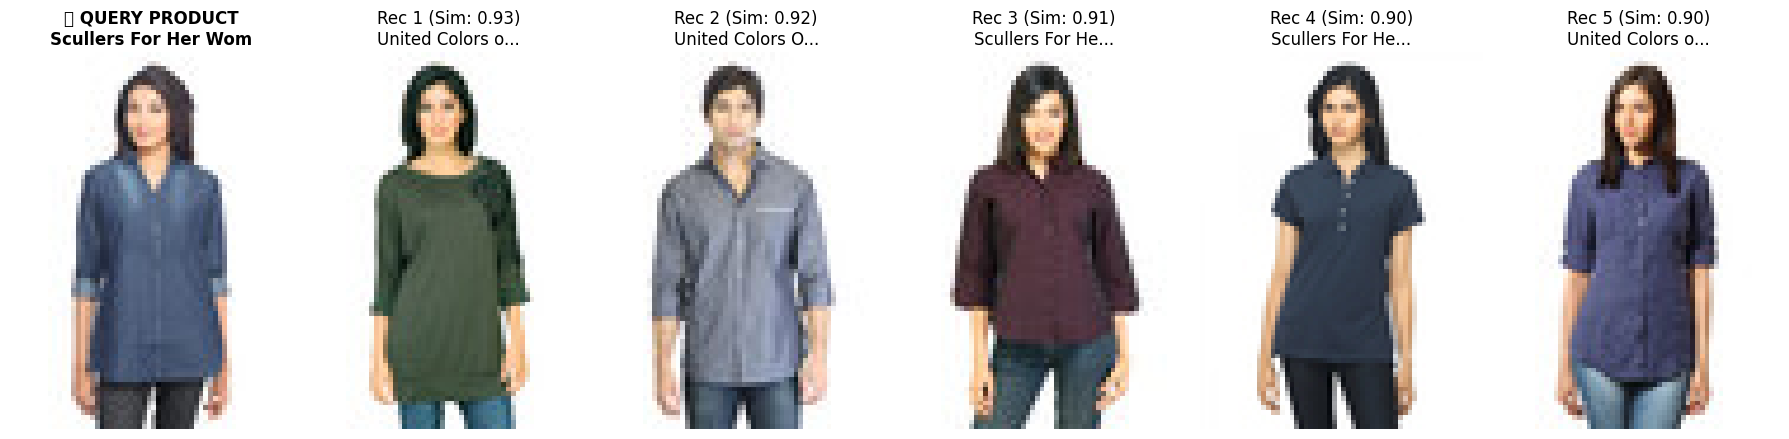

In [25]:
# Uji salah satu produk bisa juga (dari 0 sampai 4999) untuk mencoba produk lain
query_index = 150 

recommended_indices, scores = get_visual_recommendations(query_index, top_k=5)

# Visualisasi Hasil Rekomendasi
plt.figure(figsize=(18, 5))

# Gambar Target 
plt.subplot(1, 6, 1)
img_path = df['image_path'].iloc[query_index]
img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.title(f"📌 QUERY PRODUCT\n{df['productDisplayName'].iloc[query_index][:20]}", fontweight='bold')
plt.axis('off')

# Plot 5 Gambar Hasil Rekomendasi
for i, (idx, score) in enumerate(zip(recommended_indices, scores)):
    plt.subplot(1, 6, i+2)
    img_path = df['image_path'].iloc[idx]
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    
    # skor kemiripan dengan metrik
    plt.title(f"Rec {i+1} (Sim: {score:.2f})\n{df['productDisplayName'].iloc[idx][:15]}...")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Penambahan Fungsi Multimodal (Text dan Gambar)

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
import numpy as np
import pandas as pd

In [27]:
image_embeddings = np.load('image_embeddings_5k.npy')
df = pd.read_csv('filtered_metadata_5k.csv')

# Ekstraksi fitur dari nama produk (NLP)
# kita ganti nilai kosong (NaN) dengan string kosong agar tidak error
text_data = df['productDisplayName'].fillna('') + " " + df['articleType'].fillna('')

# Menggunakan TF-IDF untuk mencari kata-kata paling penting (max 500 kata)
tfidf = TfidfVectorizer(max_features=500, stop_words='english')
text_embeddings = tfidf.fit_transform(text_data).toarray()

print(f"Bentuk vektor teks (TF-IDF): {text_embeddings.shape}")

Bentuk vektor teks (TF-IDF): (5000, 500)


In [28]:
# Normalisasi
image_embeddings_norm = normalize(image_embeddings)
text_embeddings_norm = normalize(text_embeddings)

In [29]:
# Multimodal 
# 70% fokus ke visual fisik, 30% ke teks nama barang
WEIGHT_IMAGE = 0.7
WEIGHT_TEXT = 0.3

multimodal_embeddings = np.hstack((image_embeddings_norm * WEIGHT_IMAGE, text_embeddings_norm * WEIGHT_TEXT))

print(f"Bentuk vektor Multimodal Final: {multimodal_embeddings.shape}")

# Simpan hasil baru
np.save('multimodal_embeddings_5k.npy', multimodal_embeddings)
print("Vektor Multimodal berhasil disimpan")

Bentuk vektor Multimodal Final: (5000, 2548)
Vektor Multimodal berhasil disimpan
